# Ambrosini-style 1D stability map (baseline linear solver)

Этот ноутбук реализует **бэйзлайн-решатель** линейной устойчивости 1D сверхкритического течения в канале,
по механизму Ambrosini (continuity + momentum + energy → линеаризация → обобщённая спектральная задача).

Ключевое: локальные потери на входе/выходе реализованы как **δ-члены**, что в дискретизации соответствует
масштабированию **`K_in/dz`** и **`K_out/dz`** на крайних гранях (иначе карта почти не реагирует на `K_out`).

## Что выдаём
- `zR_map(NSPC,NTPC)` — критерий устойчивости (граница `zR=0`).
- `zI_map` — частота (DWO если `|zI|>eps`, Ledinegg если `|zI|≈0`).
- `ratio_map = Ttrans/T` (только в осцилляторной области).


## 0) Зависимости
- numpy, scipy, matplotlib, tqdm
- **REFPROPConnector** (как у тебя) + установленный NIST REFPROP

Если REFPROP временно недоступен, можно загрузить ранее сохранённую таблицу EOS из `.npz` (см. ниже).

In [27]:

import numpy as np
import math
from dataclasses import dataclass
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as colors

from scipy import linalg
from scipy.interpolate import PchipInterpolator


## 1) REFPROP интерфейс (без кэша)
Единицы как в твоём примере:
- `P` в **MPa**
- `T` в **°C**
- `h` в **kJ/kg**
- `rho` в **kg/m³**
- `CP` в **kJ/(kg·K)**

In [28]:

USE_REFPROP = True

try:
    from REFPROPConnector import retreive_RP_exec
    from REFPROPConnector import ThermodynamicPoint
except Exception as e:
    USE_REFPROP = False
    print("REFPROPConnector not available:", repr(e))

def setup_refprop(refprop_path: str):
    """
    Вызови один раз перед расчётами (Windows пример):
        setup_refprop(r"C:\Program Files (x86)\REFPROP\REFPROP.DLL")
    """
    if not USE_REFPROP:
        raise RuntimeError("REFPROPConnector is not available in this environment.")
    retreive_RP_exec(file_path=refprop_path)

def rp_state_PT(fluid: str, P_MPa: float, T_C: float):
    """Возвращает (rho [kg/m3], h [kJ/kg], cp [kJ/kg/K]) при P,T."""
    tp = ThermodynamicPoint([fluid], [1.0])
    tp.set_variable("P", float(P_MPa))
    tp.set_variable("T", float(T_C))
    rho = float(tp.get_variable("rho"))
    h   = float(tp.get_variable("h"))
    cp  = float(tp.get_variable("CP"))
    return rho, h, cp

def rp_state_Ph(fluid: str, P_MPa: float, h_kJkg: float):
    """Возвращает (T [°C], rho [kg/m3]) при P,h."""
    tp = ThermodynamicPoint([fluid], [1.0])
    tp.set_variable("P", float(P_MPa))
    tp.set_variable("h", float(h_kJkg))
    T_C = float(tp.get_variable("T"))
    rho = float(tp.get_variable("rho"))
    return T_C, rho

def beta_isobaric(fluid: str, P_MPa: float, T_C: float, dT_C: float = 0.05):
    """
    β = - (1/ρ) (∂ρ/∂T)_p ; центральная разность.
    Выходит в 1/K (т.к. T в °C, шаг dT в °C эквивалентен K).
    """
    rho_m, *_ = rp_state_PT(fluid, P_MPa, T_C - dT_C)
    rho_p, *_ = rp_state_PT(fluid, P_MPa, T_C + dT_C)
    rho0, *_  = rp_state_PT(fluid, P_MPa, T_C)
    drho_dT = (rho_p - rho_m) / (2.0 * dT_C)
    return - (1.0 / rho0) * drho_dT


### (опционально) инициализация REFPROP
Раскомментируй и укажи путь к DLL/so/dylib.

In [29]:
# setup_refprop(r"C:\Program Files (x86)\REFPROP\REFPROP.DLL")


## 2) Псевдокритическая точка на изобаре (max Cp)
Мы сканируем `Cp(T)` при фиксированном `P` и берём `T_pc` как максимум.
Потом берём в этой точке `rho_pc, h_pc, cp_pc`, и считаем `beta_pc` через производную плотности по T.

In [30]:

@dataclass
class PseudoCritical:
    P_MPa: float
    T_pc_C: float
    rho_pc: float
    h_pc: float
    cp_pc: float
    beta_pc: float

def find_pseudocritical(fluid: str, P_MPa: float,
                        T_min_C: float, T_max_C: float,
                        n_scan: int = 1200) -> PseudoCritical:
    Ts = np.linspace(T_min_C, T_max_C, n_scan)
    cps = np.empty_like(Ts)
    for i, T in enumerate(tqdm(Ts, desc="Scan Cp(T)")):
        _, _, cp = rp_state_PT(fluid, P_MPa, float(T))
        cps[i] = cp

    i_max = int(np.nanargmax(cps))
    T_pc = float(Ts[i_max])

    rho_pc, h_pc, cp_pc = rp_state_PT(fluid, P_MPa, T_pc)
    beta_pc = beta_isobaric(fluid, P_MPa, T_pc)

    return PseudoCritical(P_MPa, T_pc, rho_pc, h_pc, cp_pc, beta_pc)

def print_pc_sanity(pc: PseudoCritical):
    print(f"P = {pc.P_MPa:.3f} MPa")
    print(f"T_pc = {pc.T_pc_C:.3f} °C")
    print(f"rho_pc = {pc.rho_pc:.6g} kg/m^3")
    print(f"h_pc   = {pc.h_pc:.6g} kJ/kg")
    print(f"Cp_pc  = {pc.cp_pc:.6g} kJ/kg/K")
    print(f"beta_pc= {pc.beta_pc:.6g} 1/K")

    if pc.cp_pc < 0.5:
        print("⚠️ Cp_pc слишком маленький → вероятно, ошибка единиц (не дели на 1000 второй раз).")
    if pc.cp_pc > 100:
        print("⚠️ Cp_pc слишком большой → проверь единицы CP в коннекторе.")


### Запуск для воды при 25 MPa (Fig.2-like)

In [31]:

fluid = "water"
P_MPa = 25.0

pc = find_pseudocritical(fluid, P_MPa, T_min_C=250.0, T_max_C=600.0, n_scan=1400)
print_pc_sanity(pc)


Scan Cp(T): 100%|██████████| 1400/1400 [00:00<00:00, 2754.55it/s]

P = 25.000 MPa
T_pc = 384.846 °C
rho_pc = 319.013 kg/m^3
h_pc   = 2148.84 kJ/kg
Cp_pc  = 76.397 kJ/kg/K
beta_pc= 0.128527 1/K


## 3) Таблица EOS: ρ*(h*) на изобаре
Определение:

$h^* = (eta_{pc}/Cp_{pc})(h-h_{pc})$,  $h = h_{pc} + (Cp_{pc}/eta_{pc})h^*$.

`Cp_pc` должен быть в kJ/(kg·K), тогда `h` остаётся в kJ/kg.

In [32]:
@dataclass
class EOSStar:
    h_star_min: float
    h_star_max: float
    rho_star: PchipInterpolator
    drho_dh: PchipInterpolator

    @classmethod
    def from_npz(cls, path: str):
        d = np.load(path)
        hs = np.asarray(d["h_star"], dtype=float)
        rho = np.asarray(d["rho_star"], dtype=float)

        mask = np.isfinite(hs) & np.isfinite(rho) & (rho > 0.0)
        hs = hs[mask]
        rho = rho[mask]

        order = np.argsort(hs)
        hs = hs[order]
        rho = rho[order]

        hs, idx = np.unique(hs, return_index=True)
        rho = rho[idx]

        itp = PchipInterpolator(hs, rho, extrapolate=False)
        return cls(float(hs.min()), float(hs.max()), itp, itp.derivative())

    def to_npz(self, path: str, n=4000):
        hs = np.linspace(self.h_star_min, self.h_star_max, n)
        rho = self.rho_star(hs)
        np.savez(path, h_star=hs, rho_star=rho)


def _clean_eos_arrays(hs: np.ndarray, rho_star_vals: np.ndarray):
    hs = np.asarray(hs, dtype=float)
    rho_star_vals = np.asarray(rho_star_vals, dtype=float)

    mask = np.isfinite(hs) & np.isfinite(rho_star_vals) & (rho_star_vals > 0.0)
    hs = hs[mask]
    rho_star_vals = rho_star_vals[mask]

    order = np.argsort(hs)
    hs = hs[order]
    rho_star_vals = rho_star_vals[order]

    hs, idx = np.unique(hs, return_index=True)
    rho_star_vals = rho_star_vals[idx]
    return hs, rho_star_vals


def _smooth_left_tail_soft_asymptote(hs: np.ndarray,
                                     rho_star_vals: np.ndarray,
                                     H1: float = -3.4,
                                     rho_inf: float = 5.0):
    """
    Мягко заменяет левый хвост rho*(h*) асимптотическим продолжением:
        rho_left(h) = rho_inf - (rho_inf - rho1) * exp(alpha * (h - h1))
    где h1 — первая реальная точка доверенной ветви hs >= H1,
    а alpha выбирается из условия совпадения первой производной в h1.
    """
    hs, rho_star_vals = _clean_eos_arrays(hs, rho_star_vals)

    if hs.size < 20:
        raise RuntimeError("Too few valid EOS points for smoothing.")

    if not (hs.min() < H1 < hs.max()):
        raise RuntimeError(f"H1={H1} is outside EOS range [{hs.min()}, {hs.max()}].")

    core_mask = hs >= H1
    hs_core = hs[core_mask]
    rho_core = rho_star_vals[core_mask]

    if hs_core.size < 10:
        raise RuntimeError("Too few points in trust region for EOS smoothing.")

    core = PchipInterpolator(hs_core, rho_core, extrapolate=False)

    h1 = float(hs_core[0])
    rho1 = float(rho_core[0])
    drho1 = float(core.derivative()(h1))

    if not np.isfinite(rho1) or rho1 <= 0.0:
        raise RuntimeError(f"Bad rho1 at h1={h1}: {rho1}")
    if not np.isfinite(drho1):
        raise RuntimeError(f"Bad derivative at h1={h1}: {drho1}")
    if drho1 >= 0.0:
        raise RuntimeError(
            f"Expected decreasing trust branch at h1={h1}, got drho1={drho1}. "
            "Move H1 to the right."
        )
    if rho_inf <= rho1:
        raise RuntimeError(f"Need rho_inf > rho1, got rho_inf={rho_inf}, rho1={rho1}")

    A = rho_inf - rho1
    alpha = -drho1 / A
    if not np.isfinite(alpha) or alpha <= 0.0:
        raise RuntimeError(f"Bad alpha for EOS smoothing: {alpha}")

    def rho_left(h):
        h = np.asarray(h, dtype=float)
        return rho_inf - A * np.exp(alpha * (h - h1))

    rho_smooth = np.empty_like(hs, dtype=float)
    left = hs < h1
    right = ~left

    rho_smooth[left] = rho_left(hs[left])
    rho_smooth[right] = core(hs[right])

    if np.any(~np.isfinite(rho_smooth)) or np.any(rho_smooth <= 0.0):
        raise RuntimeError("Smoothed EOS contains non-finite or non-positive values.")

    return hs, rho_smooth


def build_eos_star(fluid: str, pc: PseudoCritical,
                   h_star_min: float = -8.0,
                   h_star_max: float = 14.0,
                   n_grid: int = 3000,
                   smooth_left: bool = True,
                   H1: float = -3.4,
                   rho_inf: float = 5.0,
                   save_raw_npz: str | None = None,
                   save_smooth_npz: str | None = None) -> EOSStar:
    hs = np.linspace(h_star_min, h_star_max, n_grid)
    h_phys = pc.h_pc + (pc.cp_pc / pc.beta_pc) * hs  # kJ/kg

    rho_star_raw = np.empty_like(hs)
    for i in tqdm(range(n_grid), desc="Build rho*(h*) table"):
        _, rho = rp_state_Ph(fluid, pc.P_MPa, float(h_phys[i]))
        rho_star_raw[i] = rho / pc.rho_pc

    if save_raw_npz is not None:
        np.savez(save_raw_npz, h_star=hs, rho_star=rho_star_raw)

    if smooth_left:
        hs_use, rho_use = _smooth_left_tail_soft_asymptote(
            hs, rho_star_raw, H1=H1, rho_inf=rho_inf
        )
    else:
        hs_use, rho_use = _clean_eos_arrays(hs, rho_star_raw)

    if save_smooth_npz is not None:
        np.savez(save_smooth_npz, h_star=hs_use, rho_star=rho_use)

    rho_itp = PchipInterpolator(hs_use, rho_use, extrapolate=False)
    return EOSStar(float(hs_use.min()), float(hs_use.max()), rho_itp, rho_itp.derivative())


### Строим EOS и проверяем график

Build rho*(h*) table: 100%|██████████| 3200/3200 [00:02<00:00, 1381.91it/s]


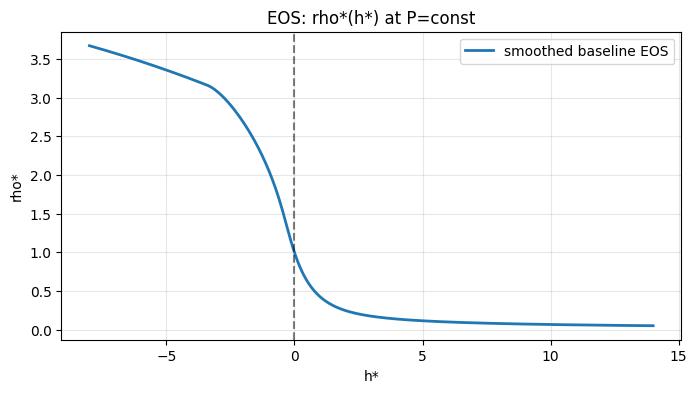

In [33]:
# eos = EOSStar.from_npz("eos_water_25MPa_smooth.npz")
eos = build_eos_star(
    fluid, pc,
    h_star_min=-8.0, h_star_max=14.0, n_grid=3200,
    smooth_left=True, H1=-3.4, rho_inf=5.0,
    save_raw_npz="eos_water_25MPa_raw.npz",
    save_smooth_npz="eos_water_25MPa_smooth.npz",
)

hs_plot = np.linspace(eos.h_star_min, eos.h_star_max, 500)
plt.figure(figsize=(8,4))
plt.plot(hs_plot, eos.rho_star(hs_plot), lw=2, label="smoothed baseline EOS")
plt.axvline(0.0, ls="--", c="k", alpha=0.5)
plt.xlabel("h*")
plt.ylabel("rho*")
plt.title("EOS: rho*(h*) at P=const")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 4) Steady-state

In [34]:

@dataclass
class SteadyState:
    N: int
    dz: float
    zc: np.ndarray
    zf: np.ndarray
    h_in_star: float
    h_star_c: np.ndarray
    rho_star_c: np.ndarray
    drho_dh_c: np.ndarray
    rho_in: float
    G_star: float
    rho_f: np.ndarray
    w_f: np.ndarray
    Ttrans_star: float
    w_max: float

def steady_state(NSPC: float, NTPC: float, N: int, eos: EOSStar) -> SteadyState:
    dz = 1.0 / N
    zc = (np.arange(N) + 0.5) * dz
    zf = np.arange(N + 1) * dz

    h_in_star = -float(NSPC)
    h_star_c = h_in_star + float(NTPC) * zc

    if (np.nanmin(h_star_c) < eos.h_star_min) or (np.nanmax(h_star_c) > eos.h_star_max):
        raise ValueError("h* leaves EOS table. Enlarge eos range.")

    rho_star_c = eos.rho_star(h_star_c)
    drho_dh_c  = eos.drho_dh(h_star_c)

    rho_in = float(eos.rho_star(h_in_star))
    G_star = rho_in

    rho_f = np.empty(N + 1)
    rho_f[0] = rho_in
    rho_f[1:] = rho_star_c

    w_f = G_star / rho_f
    Ttrans = float(np.sum(dz / w_f))
    w_max = float(np.max(w_f))

    return SteadyState(N, dz, zc, zf, h_in_star, h_star_c,
                      rho_star_c, drho_dh_c, rho_in, G_star,
                      rho_f, w_f, Ttrans, w_max)


## 5) Linear solver

In [35]:

@dataclass
class LinResult:
    mu_dom: complex
    z_dom: complex
    zR: float
    zI: float
    Ttrans_over_T: float

def build_AB(ss: SteadyState, Fr: float, Lambda: float, K_in: float, K_out: float,
             delta_scale: str = "1/dz"):
    N = ss.N
    dz = ss.dz
    Nh, Ng, Np = N, N+1, N
    M = Nh + Ng + Np

    def ih(i): return i
    def ig(j): return Nh + j
    def ip(i): return Nh + Ng + i

    A = np.zeros((M, M), dtype=float)
    B = np.zeros((M, M), dtype=float)

    # Mass
    for i in range(N):
        r = i
        B[r, ih(i)] = ss.drho_dh_c[i]
        A[r, ig(i)]   = +1.0/dz
        A[r, ig(i+1)] = -1.0/dz

    # Energy
    base_energy = N
    G0 = ss.G_star
    for i in range(N):
        r = base_energy + i
        B[r, ih(i)] = ss.rho_star_c[i] + ss.h_star_c[i] * ss.drho_dh_c[i]

        jR = i + 1
        A[r, ig(jR)] += -(ss.h_star_c[i]) / dz
        A[r, ih(i)]  += -(G0) / dz

        jL = i
        if i == 0:
            A[r, ig(jL)] += +(ss.h_in_star) / dz
        else:
            A[r, ig(jL)] += +(ss.h_star_c[i-1]) / dz
            A[r, ih(i-1)] += +(G0) / dz

    # Momentum
    base_mom = 2 * N
    rho_f = ss.rho_f
    drho_dh_f = np.zeros_like(rho_f)
    drho_dh_f[0] = 0.0
    drho_dh_f[1:] = ss.drho_dh_c

    def aG(j): return 2.0 * G0 / rho_f[j]
    def aH(j): return -(G0**2 / (rho_f[j]**2)) * drho_dh_f[j]

    def add_deltaQ_row(r, j_idx, mult):
        A[r, ig(j_idx)] += mult * aG(j_idx)
        if j_idx >= 1:
            A[r, ih(j_idx-1)] += mult * aH(j_idx)

    for j in range(Ng):
        r = base_mom + j
        B[r, ig(j)] = 1.0

        Cj = Lambda
        if j == 0:
            Cj = Lambda + (K_in/dz if delta_scale == "1/dz" else K_in)
        elif j == Ng - 1:
            Cj = Lambda + (K_out/dz if delta_scale == "1/dz" else K_out)

        if j == 0:
            add_deltaQ_row(r, 1, -1.0/dz)
            add_deltaQ_row(r, 0, +1.0/dz)
        else:
            add_deltaQ_row(r, j,   -1.0/dz)
            add_deltaQ_row(r, j-1, +1.0/dz)

        if j == 0:
            A[r, ip(0)] += -(2.0/dz)
        elif j == Ng - 1:
            A[r, ip(N-1)] += +(2.0/dz)
        else:
            A[r, ip(j)]   += -(1.0/dz)
            A[r, ip(j-1)] += +(1.0/dz)

        if j >= 1:
            A[r, ih(j-1)] += -(drho_dh_f[j] / Fr)

        A[r, ig(j)] += (-Cj) * aG(j)
        if j >= 1:
            A[r, ih(j-1)] += (-Cj) * aH(j)

    return A, B

def dominant_mode_time_discrete(A, B, dt_star: float, mu_abs_max: float = 1e6):
    RHS = B / dt_star
    LHS = (B / dt_star) - A

    mu = linalg.eigvals(RHS, LHS)
    mu = mu[np.isfinite(mu.real) & np.isfinite(mu.imag)]
    mu = mu[np.abs(mu) < mu_abs_max]
    if mu.size == 0:
        return complex(np.nan, np.nan), complex(np.nan, np.nan)

    z = np.log(mu) / dt_star
    k = int(np.argmax(z.real))
    return mu[k], z[k]

def stability_point(NSPC: float, NTPC: float, eos: EOSStar,
                    N_nodes: int, Fr: float, Lambda: float,
                    K_in: float, K_out: float,
                    Cmax: float,
                    zI_eps: float = 1e-2,
                    delta_scale: str = "1/dz") -> LinResult:
    ss = steady_state(NSPC, NTPC, N_nodes, eos)
    dt_star = Cmax * ss.dz / ss.w_max

    A, B = build_AB(ss, Fr=Fr, Lambda=Lambda, K_in=K_in, K_out=K_out, delta_scale=delta_scale)
    mu_dom, z_dom = dominant_mode_time_discrete(A, B, dt_star)

    zR = float(np.real(z_dom))
    zI = float(np.imag(z_dom))

    if abs(zI) < zI_eps or not np.isfinite(zI):
        ratio = np.nan
    else:
        ratio = float(ss.Ttrans_star * abs(zI) / (2.0 * math.pi))

    return LinResult(mu_dom=mu_dom, z_dom=z_dom, zR=zR, zI=zI, Ttrans_over_T=ratio)


## 6) Map sweep + plotting + boundary extraction
См. предыдущий python-скрипт: здесь оставлены те же ячейки для sweep/plots/contour extraction.

NSPC sweep:   0%|          | 0/41 [00:00<?, ?it/s]

C:\Users\Suchotin\AppData\Local\Temp\ipykernel_7012\1840291740.py:107: RuntimeWarning: divide by zero encountered in log
  z = np.log(mu) / dt_star
C:\Users\Suchotin\AppData\Local\Temp\ipykernel_7012\1840291740.py:107: RuntimeWarning: invalid value encountered in divide
  z = np.log(mu) / dt_star
NSPC sweep: 100%|██████████| 41/41 [00:20<00:00,  2.00it/s]


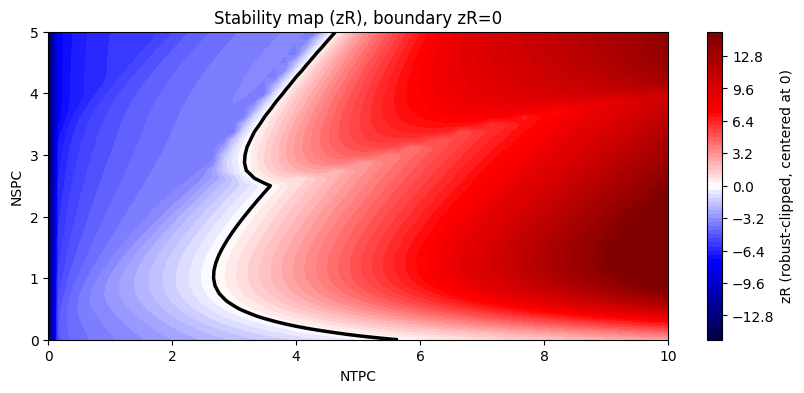

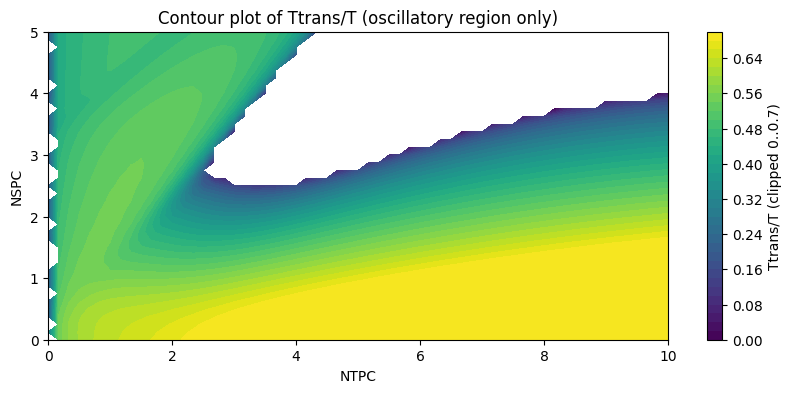

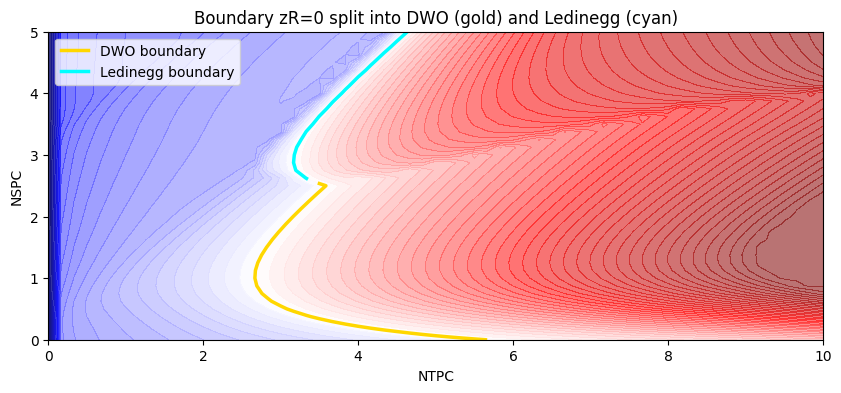

Saved: maps_water_25MPa_baseline.npz


In [36]:

# --- Config (Fig.2-like defaults, adjust if needed) ---
N_nodes = 48
Fr = 0.03
Lambda = 7.0
K_in = 20.0
K_out = 20.0
Cmax = 0.9

def compute_maps(NSPC_grid, NTPC_grid,
                 eos: EOSStar,
                 N_nodes: int, Fr: float, Lambda: float, K_in: float, K_out: float,
                 Cmax: float, zI_eps: float = 1e-2,
                 delta_scale: str = "1/dz"):
    zR_map = np.full((len(NSPC_grid), len(NTPC_grid)), np.nan, dtype=float)
    zI_map = np.full_like(zR_map, np.nan)
    ratio_map = np.full_like(zR_map, np.nan)

    for iy, NSPC in enumerate(tqdm(NSPC_grid, desc="NSPC sweep")):
        for ix, NTPC in enumerate(NTPC_grid):
            try:
                res = stability_point(float(NSPC), float(NTPC),
                                      eos=eos, N_nodes=N_nodes,
                                      Fr=Fr, Lambda=Lambda, K_in=K_in, K_out=K_out,
                                      Cmax=Cmax, zI_eps=zI_eps, delta_scale=delta_scale)
                zR_map[iy, ix] = res.zR
                zI_map[iy, ix] = res.zI
                ratio_map[iy, ix] = res.Ttrans_over_T
            except Exception:
                continue
    return zR_map, zI_map, ratio_map

NSPC_grid = np.linspace(0.0, 5.0, 41)
NTPC_grid = np.linspace(0.0, 10.0, 61)

zR_map, zI_map, ratio_map = compute_maps(
    NSPC_grid, NTPC_grid,
    eos=eos,
    N_nodes=N_nodes, Fr=Fr, Lambda=Lambda, K_in=K_in, K_out=K_out,
    Cmax=Cmax, zI_eps=1e-2, delta_scale="1/dz"
)

X, Y = np.meshgrid(NTPC_grid, NSPC_grid)

# --- zR plot (robust) ---
Z = zR_map.copy()
lo, hi = np.nanpercentile(Z, [2, 98])
m = max(abs(lo), abs(hi))
Zc = np.clip(Z, -m, m)
norm = colors.TwoSlopeNorm(vmin=-m, vcenter=0.0, vmax=m)

plt.figure(figsize=(10,4))
cf = plt.contourf(X, Y, Zc, levels=80, norm=norm, cmap="seismic")
plt.colorbar(cf, label="zR (robust-clipped, centered at 0)")
plt.contour(X, Y, Z, levels=[0.0], colors="k", linewidths=2.5)
plt.xlabel("NTPC"); plt.ylabel("NSPC")
plt.title("Stability map (zR), boundary zR=0")
plt.show()

# --- Ttrans/T (osc only) ---
zI_eps = 1e-2
R = ratio_map.copy()
R[np.abs(zI_map) < zI_eps] = np.nan
R = np.clip(R, 0.0, 0.7)

plt.figure(figsize=(10,4))
cf = plt.contourf(X, Y, R, levels=np.linspace(0, 0.7, 36), cmap="viridis")
plt.colorbar(cf, label="Ttrans/T (clipped 0..0.7)")
plt.xlabel("NTPC"); plt.ylabel("NSPC")
plt.title("Contour plot of Ttrans/T (oscillatory region only)")
plt.show()

# --- boundary extraction ---
def _nearest_on_grid(x, grid):
    return int(np.clip(np.argmin(np.abs(grid - x)), 0, len(grid)-1))

def extract_boundaries_from_contour(NTPC_grid, NSPC_grid, zR_map, zI_map, zI_eps=1e-2):
    X, Y = np.meshgrid(NTPC_grid, NSPC_grid)
    fig = plt.figure()
    CS = plt.contour(X, Y, zR_map, levels=[0.0])
    plt.close(fig)

    segs = []
    if hasattr(CS, "allsegs") and len(CS.allsegs) > 0 and len(CS.allsegs[0]) > 0:
        segs = CS.allsegs[0]
    elif hasattr(CS, "collections"):
        for col in CS.collections:
            for p in col.get_paths():
                segs.append(p.vertices)

    if not segs:
        return [], []

    dwo, led = [], []
    for v in segs:
        if v.shape[0] < 5:
            continue

        zi_abs = []
        for x, y in v:
            ix = _nearest_on_grid(x, NTPC_grid)
            iy = _nearest_on_grid(y, NSPC_grid)
            val = zI_map[iy, ix]
            zi_abs.append(abs(val) if np.isfinite(val) else 0.0)

        osc = np.array(zi_abs) > zI_eps

        start = 0
        while start < len(v):
            val = osc[start]
            end = start + 1
            while end < len(v) and osc[end] == val:
                end += 1
            seg = v[start:end]
            if seg.shape[0] >= 5:
                (dwo if val else led).append(seg)
            start = end

    return dwo, led

dwo_segs, led_segs = extract_boundaries_from_contour(NTPC_grid, NSPC_grid, zR_map, zI_map, zI_eps=zI_eps)

plt.figure(figsize=(10,4))
plt.contourf(X, Y, Zc, levels=80, norm=norm, cmap="seismic", alpha=0.55)

for i, seg in enumerate(dwo_segs):
    plt.plot(seg[:,0], seg[:,1], lw=2.5, color="gold", label="DWO boundary" if i == 0 else None)
for i, seg in enumerate(led_segs):
    plt.plot(seg[:,0], seg[:,1], lw=2.5, color="cyan", label="Ledinegg boundary" if i == 0 else None)

plt.xlabel("NTPC"); plt.ylabel("NSPC")
plt.title("Boundary zR=0 split into DWO (gold) and Ledinegg (cyan)")
plt.legend(loc="upper left")
plt.show()

# --- save ---
out_path = "maps_water_25MPa_baseline.npz"
np.savez(
    out_path,
    NSPC_grid=NSPC_grid, NTPC_grid=NTPC_grid,
    zR_map=zR_map, zI_map=zI_map, ratio_map=ratio_map,
    N_nodes=N_nodes, Fr=Fr, Lambda=Lambda, K_in=K_in, K_out=K_out, Cmax=Cmax
)
print("Saved:", out_path)


In [37]:
import numpy as np
import scipy.linalg as spla
import matplotlib.pyplot as plt
from functools import lru_cache
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


def dominant_mode_with_vector_time_discrete(A, B, dt_star: float, mu_abs_max: float = 1e6):
    RHS = B / dt_star
    LHS = (B / dt_star) - A

    mu, VR = spla.eig(RHS, LHS, right=True)

    mask = np.isfinite(mu.real) & np.isfinite(mu.imag) & (np.abs(mu) < mu_abs_max)
    mu = mu[mask]
    VR = VR[:, mask]

    if mu.size == 0:
        return complex(np.nan, np.nan), complex(np.nan, np.nan), None

    z = np.log(mu) / dt_star
    k = int(np.argmax(z.real))

    vk = VR[:, k]
    vk = vk / (np.linalg.norm(vk) + 1e-15)

    # phase fixing
    j = int(np.argmax(np.abs(vk)))
    phase = np.angle(vk[j])
    vk = vk * np.exp(-1j * phase)
    if vk[j].real < 0:
        vk = -vk

    return mu[k], z[k], vk


def build_operator_at_point(NSPC, NTPC, eos, N_nodes, Fr, Lambda, K_in, K_out, Cmax):
    ss = steady_state(float(NSPC), float(NTPC), N_nodes, eos)
    dt_star = Cmax * ss.dz / ss.w_max
    A, B = build_AB(ss, Fr=Fr, Lambda=Lambda, K_in=K_in, K_out=K_out)
    return ss, A, B, dt_star

device: cuda


In [38]:
rng = np.random.default_rng(0)

NSPC_mesh, NTPC_mesh = np.meshgrid(NSPC_grid, NTPC_grid, indexing="ij")
theta_grid = np.stack([NSPC_mesh.ravel(), NTPC_mesh.ravel()], axis=1).astype(np.float32)
n_grid_pts = theta_grid.shape[0]

print("grid size:", theta_grid.shape, " map shape:", zR_map.shape)


def choose_seed_flat_indices(zR_map,
                             stride_nspc=4,
                             stride_ntpc=4,
                             boundary_band=0.75,
                             near_band=1.50,
                             n_random_bulk=80,
                             seed=0):
    rng_local = np.random.default_rng(seed)

    coarse = np.zeros_like(zR_map, dtype=bool)
    coarse[::stride_nspc, ::stride_ntpc] = True

    boundary = np.isfinite(zR_map) & (np.abs(zR_map) <= boundary_band)
    near_boundary = np.isfinite(zR_map) & (np.abs(zR_map) <= near_band)
    valid = np.isfinite(zR_map)

    idx_coarse = np.flatnonzero(coarse)
    idx_boundary = np.flatnonzero(boundary)
    idx_near = np.flatnonzero(near_boundary)
    idx_valid = np.flatnonzero(valid)

    if idx_valid.size > 0:
        idx_bulk = rng_local.choice(idx_valid, size=min(n_random_bulk, idx_valid.size), replace=False)
    else:
        idx_bulk = np.array([], dtype=int)

    seed_idx = np.unique(np.concatenate([idx_coarse, idx_boundary, idx_near, idx_bulk]))
    return seed_idx


seed_flat_idx = choose_seed_flat_indices(
    zR_map,
    stride_nspc=4,
    stride_ntpc=4,
    boundary_band=0.75,
    near_band=1.50,
    n_random_bulk=80,
    seed=0
)

print("number of sparse seed points:", len(seed_flat_idx))

grid size: (2501, 2)  map shape: (41, 61)
number of sparse seed points: 497


In [39]:
seed_theta = []
seed_z = []
seed_v = []

for flat_idx in tqdm(seed_flat_idx, desc="Build sparse seed library"):
    NSPC, NTPC = theta_grid[int(flat_idx)]

    try:
        ss, A, B, dt_star = build_operator_at_point(
            NSPC, NTPC, eos,
            N_nodes=N_nodes,
            Fr=Fr, Lambda=Lambda,
            K_in=K_in, K_out=K_out,
            Cmax=Cmax
        )

        _, z_seed, v_seed = dominant_mode_with_vector_time_discrete(A, B, dt_star)

        if v_seed is None:
            continue
        if not (np.isfinite(np.real(z_seed)) and np.isfinite(np.imag(z_seed))):
            continue

        seed_theta.append([float(NSPC), float(NTPC)])
        seed_z.append(z_seed)
        seed_v.append(v_seed)

    except Exception:
        continue

seed_theta = np.asarray(seed_theta, dtype=np.float32)
seed_z = np.asarray(seed_z, dtype=np.complex128)
seed_V = np.column_stack(seed_v)  # shape (M, Ns)

print("seed_theta:", seed_theta.shape)
print("seed_z:", seed_z.shape)
print("seed_V:", seed_V.shape)

Build sparse seed library:   0%|          | 0/497 [00:00<?, ?it/s]C:\Users\Suchotin\AppData\Local\Temp\ipykernel_7012\3017500777.py:28: RuntimeWarning: divide by zero encountered in log
  z = np.log(mu) / dt_star
C:\Users\Suchotin\AppData\Local\Temp\ipykernel_7012\3017500777.py:28: RuntimeWarning: invalid value encountered in divide
  z = np.log(mu) / dt_star
Build sparse seed library: 100%|██████████| 497/497 [00:09<00:00, 52.62it/s]

seed_theta: (497, 2)
seed_z: (497,)
seed_V: (145, 497)


In [40]:
# POD basis from sparse dominant modes
U_full, svals, _ = np.linalg.svd(seed_V, full_matrices=False)

K_POD = min(12, U_full.shape[1])   # 8..16 usually a good range
U_pod = U_full[:, :K_POD]          # shape (M, K)

# project sparse seed modes to POD coefficients
C_seed = U_pod.conj().T @ seed_V   # shape (K, Ns)

print("K_POD =", K_POD)
print("singular values:", svals[:min(12, len(svals))])

# anchors = sparse seed points
anchor_theta = seed_theta.copy()
anchor_zR = np.real(seed_z).reshape(-1, 1).astype(np.float32)
anchor_logzI = np.log(np.abs(np.imag(seed_z)).reshape(-1, 1).astype(np.float32) + 1e-6)

anchor_cre = np.real(C_seed.T).astype(np.float32)   # (Ns, K)
anchor_cim = np.imag(C_seed.T).astype(np.float32)   # (Ns, K)

anchor_targets = np.concatenate(
    [anchor_zR, anchor_logzI, anchor_cre, anchor_cim],
    axis=1
).astype(np.float32)

print("anchor_theta:", anchor_theta.shape)
print("anchor_targets:", anchor_targets.shape)

# normalization
x_mean = theta_grid.mean(axis=0, keepdims=True).astype(np.float32)
x_std = theta_grid.std(axis=0, keepdims=True).astype(np.float32)
x_std = np.maximum(x_std, 1e-6)

y_mean = anchor_targets.mean(axis=0, keepdims=True).astype(np.float32)
y_std = anchor_targets.std(axis=0, keepdims=True).astype(np.float32)
y_std = np.maximum(y_std, 1e-6)

# tensors
x_mean_t = torch.tensor(x_mean, dtype=torch.float32, device=device)
x_std_t = torch.tensor(x_std, dtype=torch.float32, device=device)

y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_std, dtype=torch.float32, device=device)

anchor_theta_t = torch.tensor(anchor_theta, dtype=torch.float32, device=device)
anchor_targets_t = torch.tensor(anchor_targets, dtype=torch.float32, device=device)
anchor_targets_n_t = (anchor_targets_t - y_mean_t) / y_std_t

# complex POD basis on device
U_t = torch.tensor(U_pod.T, dtype=torch.complex64, device=device)  # shape (K, M)

# reference component for phase regularization
phase_idx = int(np.argmax(np.mean(np.abs(seed_V), axis=1)))
print("phase_idx =", phase_idx)

K_POD = 12
singular values: [22.06045062  2.8070981   1.10420594  0.86101368  0.48770923  0.3474714
  0.21835011  0.20608249  0.12912087  0.10344935  0.09753775  0.05906914]
anchor_theta: (497, 2)
anchor_targets: (497, 26)
phase_idx = 128


In [41]:
# POD basis from sparse dominant modes
U_full, svals, _ = np.linalg.svd(seed_V, full_matrices=False)

K_POD = min(12, U_full.shape[1])   # 8..16 usually a good range
U_pod = U_full[:, :K_POD]          # shape (M, K)

# project sparse seed modes to POD coefficients
C_seed = U_pod.conj().T @ seed_V   # shape (K, Ns)

print("K_POD =", K_POD)
print("singular values:", svals[:min(12, len(svals))])

# anchors = sparse seed points
anchor_theta = seed_theta.copy()
anchor_zR = np.real(seed_z).reshape(-1, 1).astype(np.float32)
anchor_logzI = np.log(np.abs(np.imag(seed_z)).reshape(-1, 1).astype(np.float32) + 1e-6)

anchor_cre = np.real(C_seed.T).astype(np.float32)   # (Ns, K)
anchor_cim = np.imag(C_seed.T).astype(np.float32)   # (Ns, K)

anchor_targets = np.concatenate(
    [anchor_zR, anchor_logzI, anchor_cre, anchor_cim],
    axis=1
).astype(np.float32)

print("anchor_theta:", anchor_theta.shape)
print("anchor_targets:", anchor_targets.shape)

# normalization
x_mean = theta_grid.mean(axis=0, keepdims=True).astype(np.float32)
x_std = theta_grid.std(axis=0, keepdims=True).astype(np.float32)
x_std = np.maximum(x_std, 1e-6)

y_mean = anchor_targets.mean(axis=0, keepdims=True).astype(np.float32)
y_std = anchor_targets.std(axis=0, keepdims=True).astype(np.float32)
y_std = np.maximum(y_std, 1e-6)

# tensors
x_mean_t = torch.tensor(x_mean, dtype=torch.float32, device=device)
x_std_t = torch.tensor(x_std, dtype=torch.float32, device=device)

y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_std, dtype=torch.float32, device=device)

anchor_theta_t = torch.tensor(anchor_theta, dtype=torch.float32, device=device)
anchor_targets_t = torch.tensor(anchor_targets, dtype=torch.float32, device=device)
anchor_targets_n_t = (anchor_targets_t - y_mean_t) / y_std_t

# complex POD basis on device
U_t = torch.tensor(U_pod.T, dtype=torch.complex64, device=device)  # shape (K, M)

# reference component for phase regularization
phase_idx = int(np.argmax(np.mean(np.abs(seed_V), axis=1)))
print("phase_idx =", phase_idx)

K_POD = 12
singular values: [22.06045062  2.8070981   1.10420594  0.86101368  0.48770923  0.3474714
  0.21835011  0.20608249  0.12912087  0.10344935  0.09753775  0.05906914]
anchor_theta: (497, 2)
anchor_targets: (497, 26)
phase_idx = 128


In [42]:
@lru_cache(maxsize=512)
def get_operator_cached(flat_idx: int):
    NSPC, NTPC = theta_grid[int(flat_idx)]

    ss, A, B, dt_star = build_operator_at_point(
        float(NSPC), float(NTPC), eos,
        N_nodes=N_nodes,
        Fr=Fr, Lambda=Lambda,
        K_in=K_in, K_out=K_out,
        Cmax=Cmax
    )

    RHS = (B / dt_star).astype(np.complex64)
    LHS = ((B / dt_star) - A).astype(np.complex64)
    return RHS, LHS, float(dt_star)


def anchor_loss(anchor_idx_batch):
    theta_b = anchor_theta_t[anchor_idx_batch]
    targ_n = anchor_targets_n_t[anchor_idx_batch]

    pred_n = model(normalize_x_t(theta_b))
    err = pred_n - targ_n

    # stronger on z, lighter on coeffs
    Lz = 6.0 * (err[:, :2]**2).mean()
    Lc = 1.0 * (err[:, 2:]**2).mean()
    return Lz + Lc


def smoothness_loss(theta_batch_t):
    theta_batch_t = theta_batch_t.clone().detach().requires_grad_(True)

    out_n = model(normalize_x_t(theta_batch_t))
    zR_n = out_n[:, 0:1]
    logzI_n = out_n[:, 1:2]
    coeff_energy = (out_n[:, 2:]**2).mean(dim=1, keepdim=True)

    gzR = torch.autograd.grad(zR_n.sum(), theta_batch_t, create_graph=True)[0]
    gzI = torch.autograd.grad(logzI_n.sum(), theta_batch_t, create_graph=True)[0]
    gc = torch.autograd.grad(coeff_energy.sum(), theta_batch_t, create_graph=True)[0]

    Ls = (gzR**2).mean() + 0.5*(gzI**2).mean() + 0.1*(gc**2).mean()
    return Ls


def physics_loss(flat_idx_batch):
    theta_b = torch.tensor(theta_grid[flat_idx_batch], dtype=torch.float32, device=device)
    zR, zI, cre, cim, v = predict_on_theta_t(theta_b)
    z = torch.complex(zR[:, 0], zI[:, 0])

    phys_terms = []
    phase_terms = []

    for b, flat_idx in enumerate(flat_idx_batch):
        RHS_np, LHS_np, dt_star = get_operator_cached(int(flat_idx))

        RHS_t = torch.tensor(RHS_np, dtype=torch.complex64, device=device)
        LHS_t = torch.tensor(LHS_np, dtype=torch.complex64, device=device)
        dt_t = torch.tensor(dt_star, dtype=torch.float32, device=device)

        mu = torch.exp(z[b] * dt_t)
        r = RHS_t @ v[b] - mu * (LHS_t @ v[b])

        Lr = torch.sum(torch.abs(r)**2) / (torch.sum(torch.abs(v[b])**2) + 1e-12)
        phys_terms.append(Lr)

        vp = v[b, phase_idx]
        phase_terms.append(vp.imag**2 + F.relu(-vp.real)**2)

    L_phys = torch.stack(phys_terms).mean()
    L_phase = torch.stack(phase_terms).mean()
    L_dom = -zR.mean()   # mild bias toward dominant branch
    return L_phys, L_phase, L_dom

In [44]:
class GlobalOperatorPINN(nn.Module):
    def __init__(self, K, width=160, depth=4):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 2 + 2*K)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def normalize_x_t(theta_t):
    return (theta_t - x_mean_t) / x_std_t

def decode_outputs_t(out_n):
    y = out_n * y_std_t + y_mean_t

    zR = y[:, 0:1]
    logzI = y[:, 1:2]
    zI = torch.exp(logzI).clamp_min(1e-6)

    cre = y[:, 2:2+K_POD]
    cim = y[:, 2+K_POD:2+2*K_POD]
    return zR, zI, cre, cim

def reconstruct_mode_t(cre, cim):
    c = torch.complex(cre, cim)      # (B, K)
    v = c @ U_t                      # (B, M)
    v = v / (torch.linalg.norm(v, dim=1, keepdim=True) + 1e-12)
    return v

def predict_on_theta_t(theta_t):
    out_n = model(normalize_x_t(theta_t))
    zR, zI, cre, cim = decode_outputs_t(out_n)
    v = reconstruct_mode_t(cre, cim)
    return zR, zI, cre, cim, v

model = GlobalOperatorPINN(K=K_POD, width=160, depth=4).to(device)
print(model)

GlobalOperatorPINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=160, bias=True)
    (1): Tanh()
    (2): Linear(in_features=160, out_features=160, bias=True)
    (3): Tanh()
    (4): Linear(in_features=160, out_features=160, bias=True)
    (5): Tanh()
    (6): Linear(in_features=160, out_features=160, bias=True)
    (7): Tanh()
    (8): Linear(in_features=160, out_features=26, bias=True)
  )
)


Warm start: anchors + smoothness:   0%|          | 0/1200 [00:00<?, ?it/s]

Warm start: anchors + smoothness: 100%|██████████| 1200/1200 [00:11<00:00, 104.41it/s, anchor=0.58, smooth=1.76, total=0.598] 


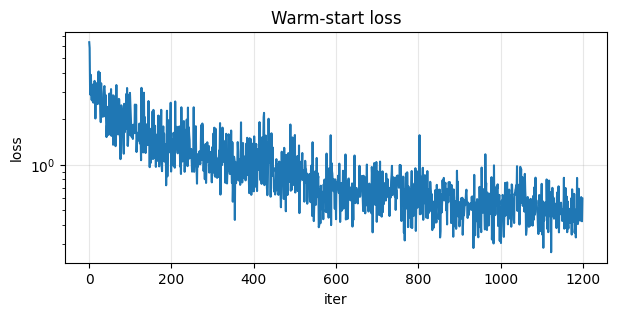

In [45]:
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

n_warm = 1200
anchor_batch = min(96, len(anchor_theta))
smooth_batch = 64

warm_hist = []

pbar = tqdm(range(n_warm), desc="Warm start: anchors + smoothness")
for it in pbar:
    aidx = rng.choice(len(anchor_theta), size=anchor_batch, replace=False)
    sidx = rng.choice(n_grid_pts, size=smooth_batch, replace=False)

    theta_s = torch.tensor(theta_grid[sidx], dtype=torch.float32, device=device)

    L_anchor = anchor_loss(aidx)
    L_smooth = smoothness_loss(theta_s)

    loss = 1.0 * L_anchor + 0.01 * L_smooth

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    warm_hist.append(float(loss.detach().cpu()))

    if (it + 1) % 100 == 0:
        pbar.set_postfix(
            total=float(loss.detach().cpu()),
            anchor=float(L_anchor.detach().cpu()),
            smooth=float(L_smooth.detach().cpu()),
        )

plt.figure(figsize=(7,3))
plt.plot(warm_hist)
plt.yscale("log")
plt.title("Warm-start loss")
plt.xlabel("iter")
plt.ylabel("loss")
plt.grid(True, alpha=0.3)
plt.show()

Hybrid global operator-PINN: 100%|██████████| 2200/2200 [02:49<00:00, 13.00it/s, anchor=2.22, phase=7.26e-5, phys=2.11, smooth=0.725, total=2.57, zbias=-0.171]


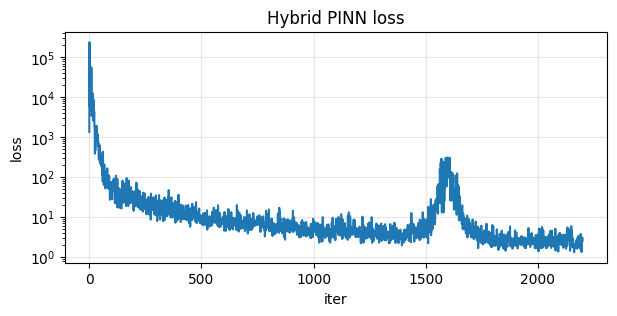

In [46]:
opt = torch.optim.Adam(model.parameters(), lr=1.5e-3)

n_hybrid = 2200
anchor_batch = min(96, len(anchor_theta))
physics_batch = 12
smooth_batch = 64

hybrid_hist = []

pbar = tqdm(range(n_hybrid), desc="Hybrid global operator-PINN")
for it in pbar:
    aidx = rng.choice(len(anchor_theta), size=anchor_batch, replace=False)
    pidx = rng.choice(n_grid_pts, size=physics_batch, replace=False)
    sidx = rng.choice(n_grid_pts, size=smooth_batch, replace=False)

    theta_s = torch.tensor(theta_grid[sidx], dtype=torch.float32, device=device)

    L_anchor = anchor_loss(aidx)
    L_phys, L_phase, L_dom = physics_loss(pidx)
    L_smooth = smoothness_loss(theta_s)

    loss = (
        1.00 * L_phys
        + 0.20 * L_anchor
        + 0.05 * L_phase
        + 0.02 * L_smooth
        + 0.001 * L_dom
    )

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    hybrid_hist.append(float(loss.detach().cpu()))

    if (it + 1) % 100 == 0:
        pbar.set_postfix(
            total=float(loss.detach().cpu()),
            phys=float(L_phys.detach().cpu()),
            anchor=float(L_anchor.detach().cpu()),
            phase=float(L_phase.detach().cpu()),
            smooth=float(L_smooth.detach().cpu()),
            zbias=float(L_dom.detach().cpu()),
        )

plt.figure(figsize=(7,3))
plt.plot(hybrid_hist)
plt.yscale("log")
plt.title("Hybrid PINN loss")
plt.xlabel("iter")
plt.ylabel("loss")
plt.grid(True, alpha=0.3)
plt.show()

In [47]:
@torch.no_grad()
def predict_full_maps(model):
    theta_t = torch.tensor(theta_grid, dtype=torch.float32, device=device)
    zR, zI, cre, cim, v = predict_on_theta_t(theta_t)

    zR_pred = zR[:, 0].detach().cpu().numpy().reshape(zR_map.shape)
    zI_pred = zI[:, 0].detach().cpu().numpy().reshape(zI_map.shape)
    return zR_pred, zI_pred


zR_pinn_map, zI_pinn_map = predict_full_maps(model)

print("prediction done")
print("finite zR points:", np.isfinite(zR_pinn_map).sum(), "/", zR_pinn_map.size)

prediction done
finite zR points: 2501 / 2501


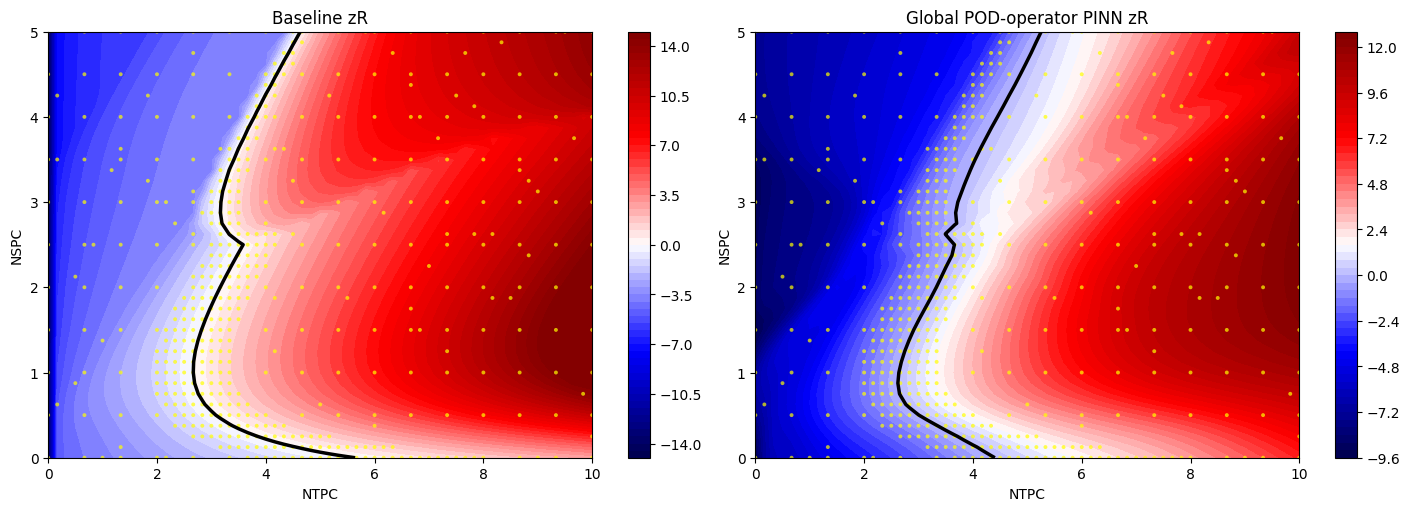

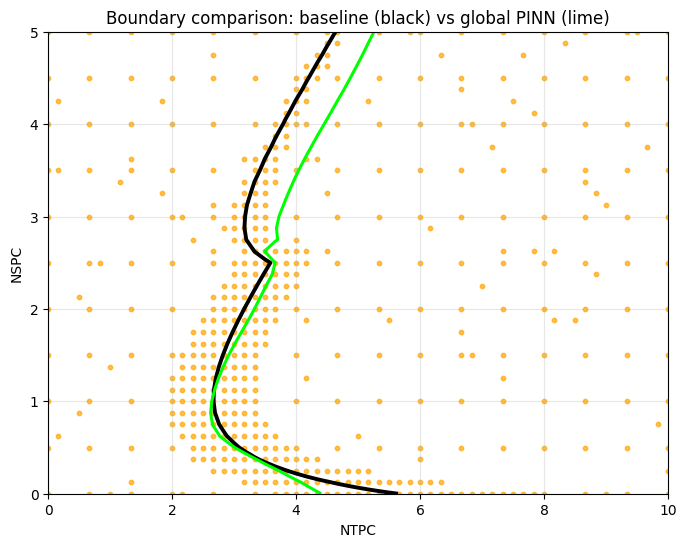

In [50]:
X, Y = np.meshgrid(NTPC_grid, NSPC_grid)

def robust_clip(Z):
    lo, hi = np.nanpercentile(Z, [2, 98])
    m = max(abs(lo), abs(hi))
    return np.clip(Z, -m, m), m

Zb, mb = robust_clip(zR_map)
Zp, mp = robust_clip(zR_pinn_map)
m = max(mb, mp)

fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

cf0 = axs[0].contourf(X, Y, np.clip(zR_map, -m, m), levels=70, cmap="seismic")
axs[0].contour(X, Y, zR_map, levels=[0.0], colors="k", linewidths=2.5)
axs[0].scatter(anchor_theta[:,1], anchor_theta[:,0], s=8, c="yellow", alpha=0.7, edgecolors="none")
axs[0].set_title("Baseline zR")
axs[0].set_xlabel("NTPC")
axs[0].set_ylabel("NSPC")
plt.colorbar(cf0, ax=axs[0])

cf1 = axs[1].contourf(X, Y, np.clip(zR_pinn_map, -m, m), levels=70, cmap="seismic")
axs[1].contour(X, Y, zR_pinn_map, levels=[0.0], colors="k", linewidths=2.5)
axs[1].scatter(anchor_theta[:,1], anchor_theta[:,0], s=8, c="yellow", alpha=0.7, edgecolors="none")
axs[1].set_title("Global POD-operator PINN zR")
axs[1].set_xlabel("NTPC")
axs[1].set_ylabel("NSPC")
plt.colorbar(cf1, ax=axs[1])

plt.show()

plt.figure(figsize=(8, 6))
plt.contour(X, Y, zR_map, levels=[0.0], colors="k", linewidths=2.8)
plt.contour(X, Y, zR_pinn_map, levels=[0.0], colors="lime", linewidths=2.2)
plt.scatter(anchor_theta[:,1], anchor_theta[:,0], s=10, c="orange", alpha=0.7)
plt.xlabel("NTPC")
plt.ylabel("NSPC")
plt.title("Boundary comparison: baseline (black) vs global PINN (lime)")
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
mask = np.isfinite(zR_map) & np.isfinite(zR_pinn_map) & np.isfinite(zI_map) & np.isfinite(zI_pinn_map)

err_zR = zR_pinn_map[mask] - zR_map[mask]
err_zI = zI_pinn_map[mask] - zI_map[mask]

print("MAE zR  =", float(np.mean(np.abs(err_zR))))
print("RMSE zR =", float(np.sqrt(np.mean(err_zR**2))))
print("MAE zI  =", float(np.mean(np.abs(err_zI))))
print("RMSE zI =", float(np.sqrt(np.mean(err_zI**2))))
print("valid points =", int(mask.sum()), "/", mask.size)

MAE zR  = 1.7104604126491947
RMSE zR = 2.638557924794818
MAE zI  = 5.48666262220767
RMSE zI = 8.98193664598433
valid points = 2501 / 2501
